# Разведочный анализ данных. Исследование и визуализация данных.

В качестве набора данных для анализа и визуализации был выбран набор данных об успеваемости и привычках студентов университетов

https://www.kaggle.com/datasets/robiulhasanjisan/university-student-performance-and-habits-dataset/data

# Загрузка библиотек и данных


In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



Данные были загружены с помощью кода с Kaggle, после загрузки на компьютер я их перенесла в свою папку с кодом и с помощью запроса ниже присвоила переменной data таблицу с данными.

In [140]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("robiulhasanjisan/university-student-performance-and-habits-dataset")

print("Path to dataset files:", path)

Path to dataset files: /Users/anlimka/.cache/kagglehub/datasets/robiulhasanjisan/university-student-performance-and-habits-dataset/versions/1


In [141]:
data = pd.read_csv('Student_data.csv', sep=',')
data.head()

,Student_ID,Gender,Age,Major,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,ID00001,Male,20,Engineering,83.9,4.4,2.65,9.1,8,2.78
1,ID00002,Female,24,Business,80.7,4.0,3.58,4.0,4,3.76
2,ID00003,Female,20,Mathematics,91.5,3.9,3.29,6.7,4,3.75
3,ID00004,Female,23,Engineering,73.9,8.8,3.48,4.0,6,3.69
4,ID00005,Male,21,Economics,79.8,2.2,2.66,8.7,6,2.34


# Основные характеристики датасета

In [142]:
# Размер датасета - 5000 строк, 10 колонок
data.shape

(5000, 10)

In [143]:
total_count = data.shape[0]
print(f'Всего строк: {total_count}')

Всего строк: 5000


In [144]:
# Список колонок
data.columns

Index(['Student_ID', 'Gender', 'Age', 'Major', 'Attendance_Pct',
       'Study_Hours_Per_Day', 'Previous_GPA', 'Sleep_Hours',
       'Social_Hours_Week', 'Final_CGPA'],
      dtype='object')

In [145]:
# Список колонок с типами данных
data.dtypes

Student_ID              object
Gender                  object
Age                      int64
Major                   object
Attendance_Pct         float64
Study_Hours_Per_Day    float64
Previous_GPA           float64
Sleep_Hours            float64
Social_Hours_Week        int64
Final_CGPA             float64
dtype: object

In [146]:
# Проверка на наличие пустных значений
for col in data.columns:
    # Количество пустых значений - все значения заполнены
    null_count = data[data[col].isnull()].shape[0]
    print('{} - {}'.format(col, null_count))

Student_ID - 0
Gender - 0
Age - 0
Major - 0
Attendance_Pct - 0
Study_Hours_Per_Day - 0
Previous_GPA - 0
Sleep_Hours - 0
Social_Hours_Week - 0
Final_CGPA - 0


In [147]:
# Основные статистические характеристки набора данных
data.describe()

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.948600,83.795740,4.517840,3.093824,7.012060,8.006400,3.272224
std,2.017417,12.867904,2.568104,0.476754,1.424377,2.797771,0.507954
min,18.000000,26.200000,0.100000,1.350000,4.000000,0.000000,1.160000
25%,19.000000,75.100000,2.600000,2.760000,6.000000,6.000000,2.920000
50%,21.000000,85.050000,4.000000,3.100000,7.000000,8.000000,3.310000
75%,23.000000,94.800000,6.000000,3.430000,8.000000,10.000000,3.680000
max,24.000000,100.000000,14.000000,4.000000,10.000000,20.000000,4.000000


In [148]:
# Определим уникальные значения для признака Gender
data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

# Визуальное исследование

<Axes: xlabel='Attendance_Pct', ylabel='Final_CGPA'>

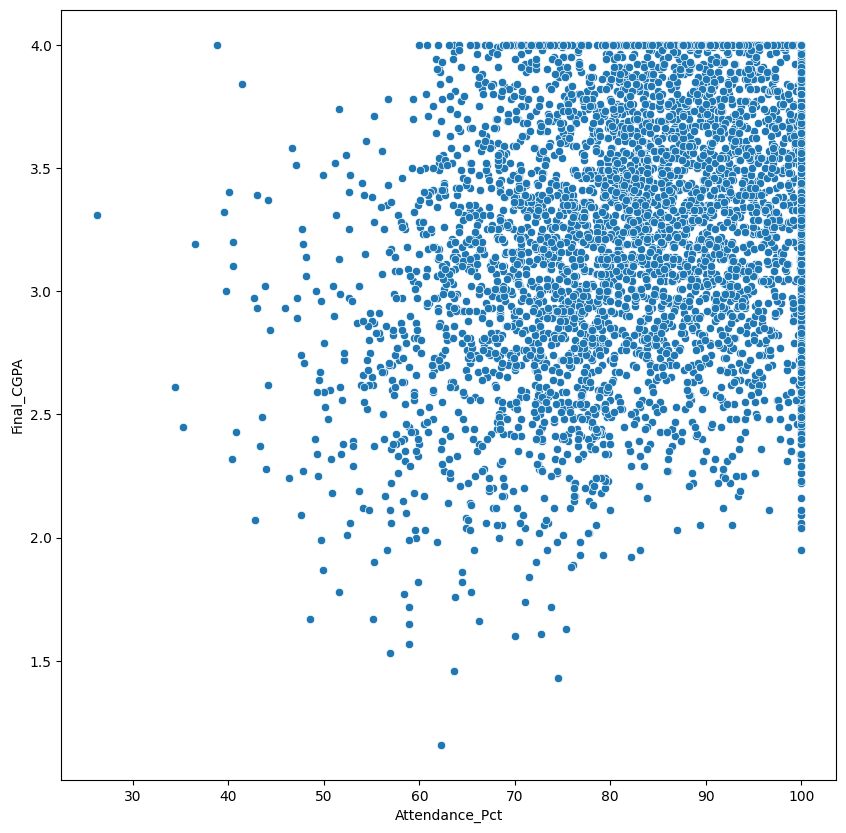

In [149]:
#построение диаграммы рассеяния 
fig, ax = plt.subplots(figsize=(10,10)) 
sns.scatterplot(ax=ax, x='Attendance_Pct', y='Final_CGPA', data=data)

Можно увидеть, что финальная оценка не имеет явной зависимости от посещаемости студента
Построим гистограмму распредения данных по часам сна.

P.s. Функция distplot видимо больше не поддерживается библиотекой или поменяла название, из-за чего выдает ошибку, поэтому я построила гистограмму с помощью предложенной vs code функцией hisplot

<Axes: xlabel='Sleep_Hours', ylabel='Count'>

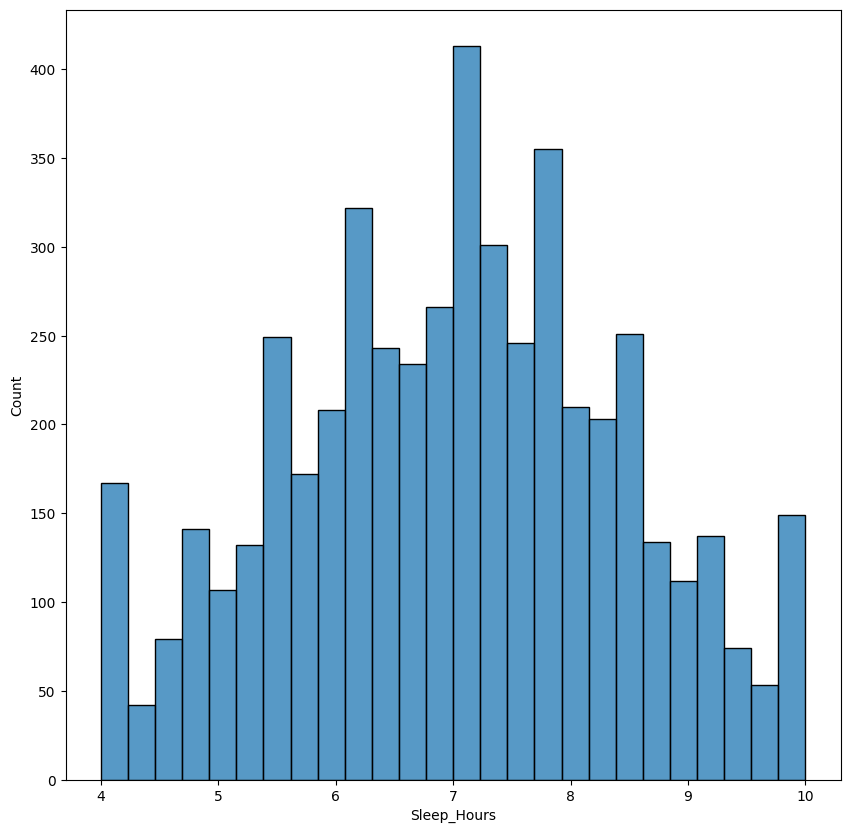

In [150]:
fig, ax = plt.subplots(figsize=(10,10)) 
sns.histplot(data['Sleep_Hours'])

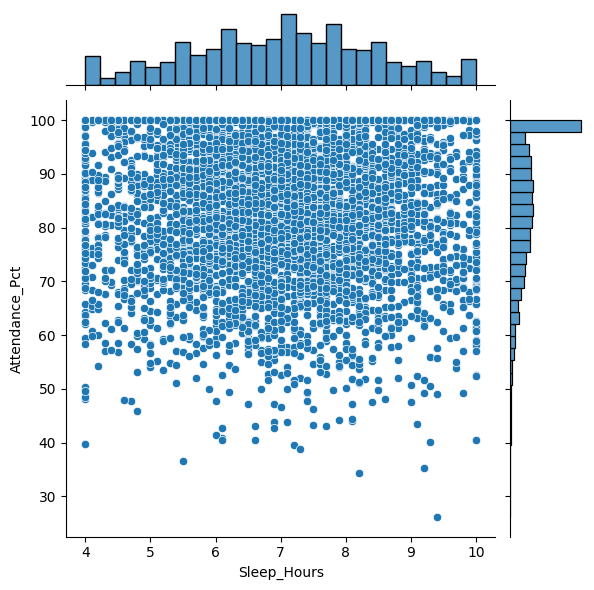

In [151]:
#Комбинация гистограмм и диаграмм рассеивания.
sns.jointplot(x='Sleep_Hours', y='Attendance_Pct', data=data)

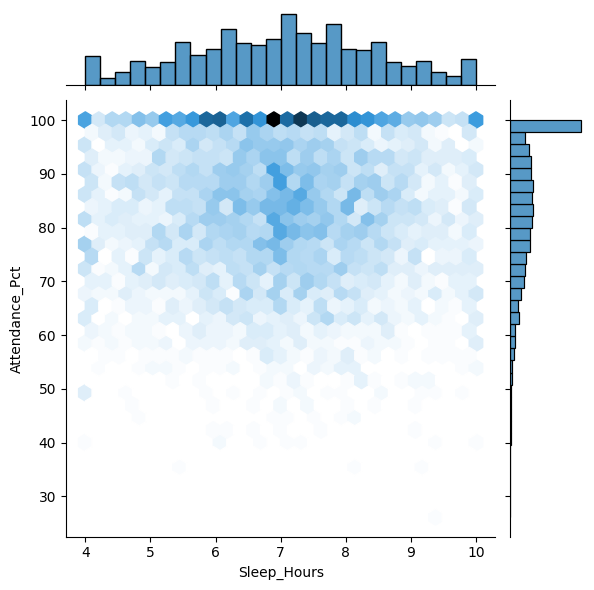

In [152]:
sns.jointplot(x='Sleep_Hours', y='Attendance_Pct', data=data, kind="hex")

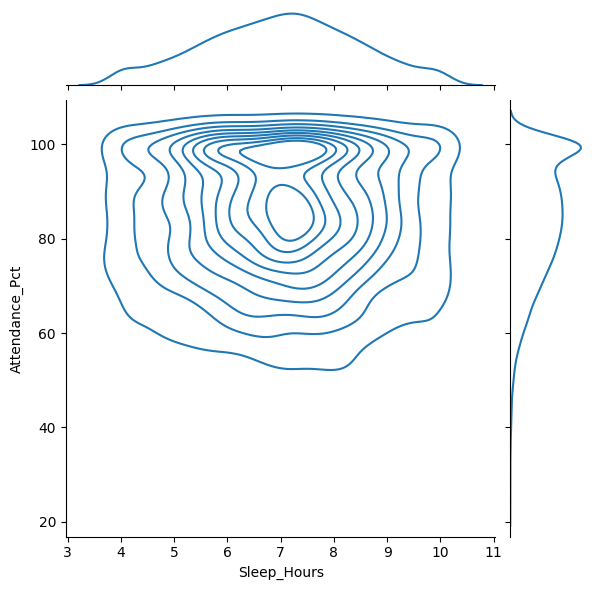

In [153]:
sns.jointplot(x='Sleep_Hours', y='Attendance_Pct', data=data, kind="kde")

## Преобразование датасета
В моем датасете содержатся столбики с данными типа object. Чтобы было проще работать с данными и строить соответсвующие графики, я создала отдельную переменную data_new, в которую добавила все данные, кроме типа object.

In [154]:
data_new = data.drop(data.columns[[0,1,3]], axis = 1)
data_new.head()


,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
0,20,83.9,4.4,2.65,9.1,8,2.78
1,24,80.7,4.0,3.58,4.0,4,3.76
2,20,91.5,3.9,3.29,6.7,4,3.75
3,23,73.9,8.8,3.48,4.0,6,3.69
4,21,79.8,2.2,2.66,8.7,6,2.34


Парные диаграммы
Комбинация гистограмм и диаграмм рассеивания для всего набора данных.

Выводится матрица графиков. На пересечении строки и столбца, которые соответстуют двум показателям, строится диаграмма рассеивания. В главной диагонали матрицы строятся гистограммы распределения соответствующих показателей.

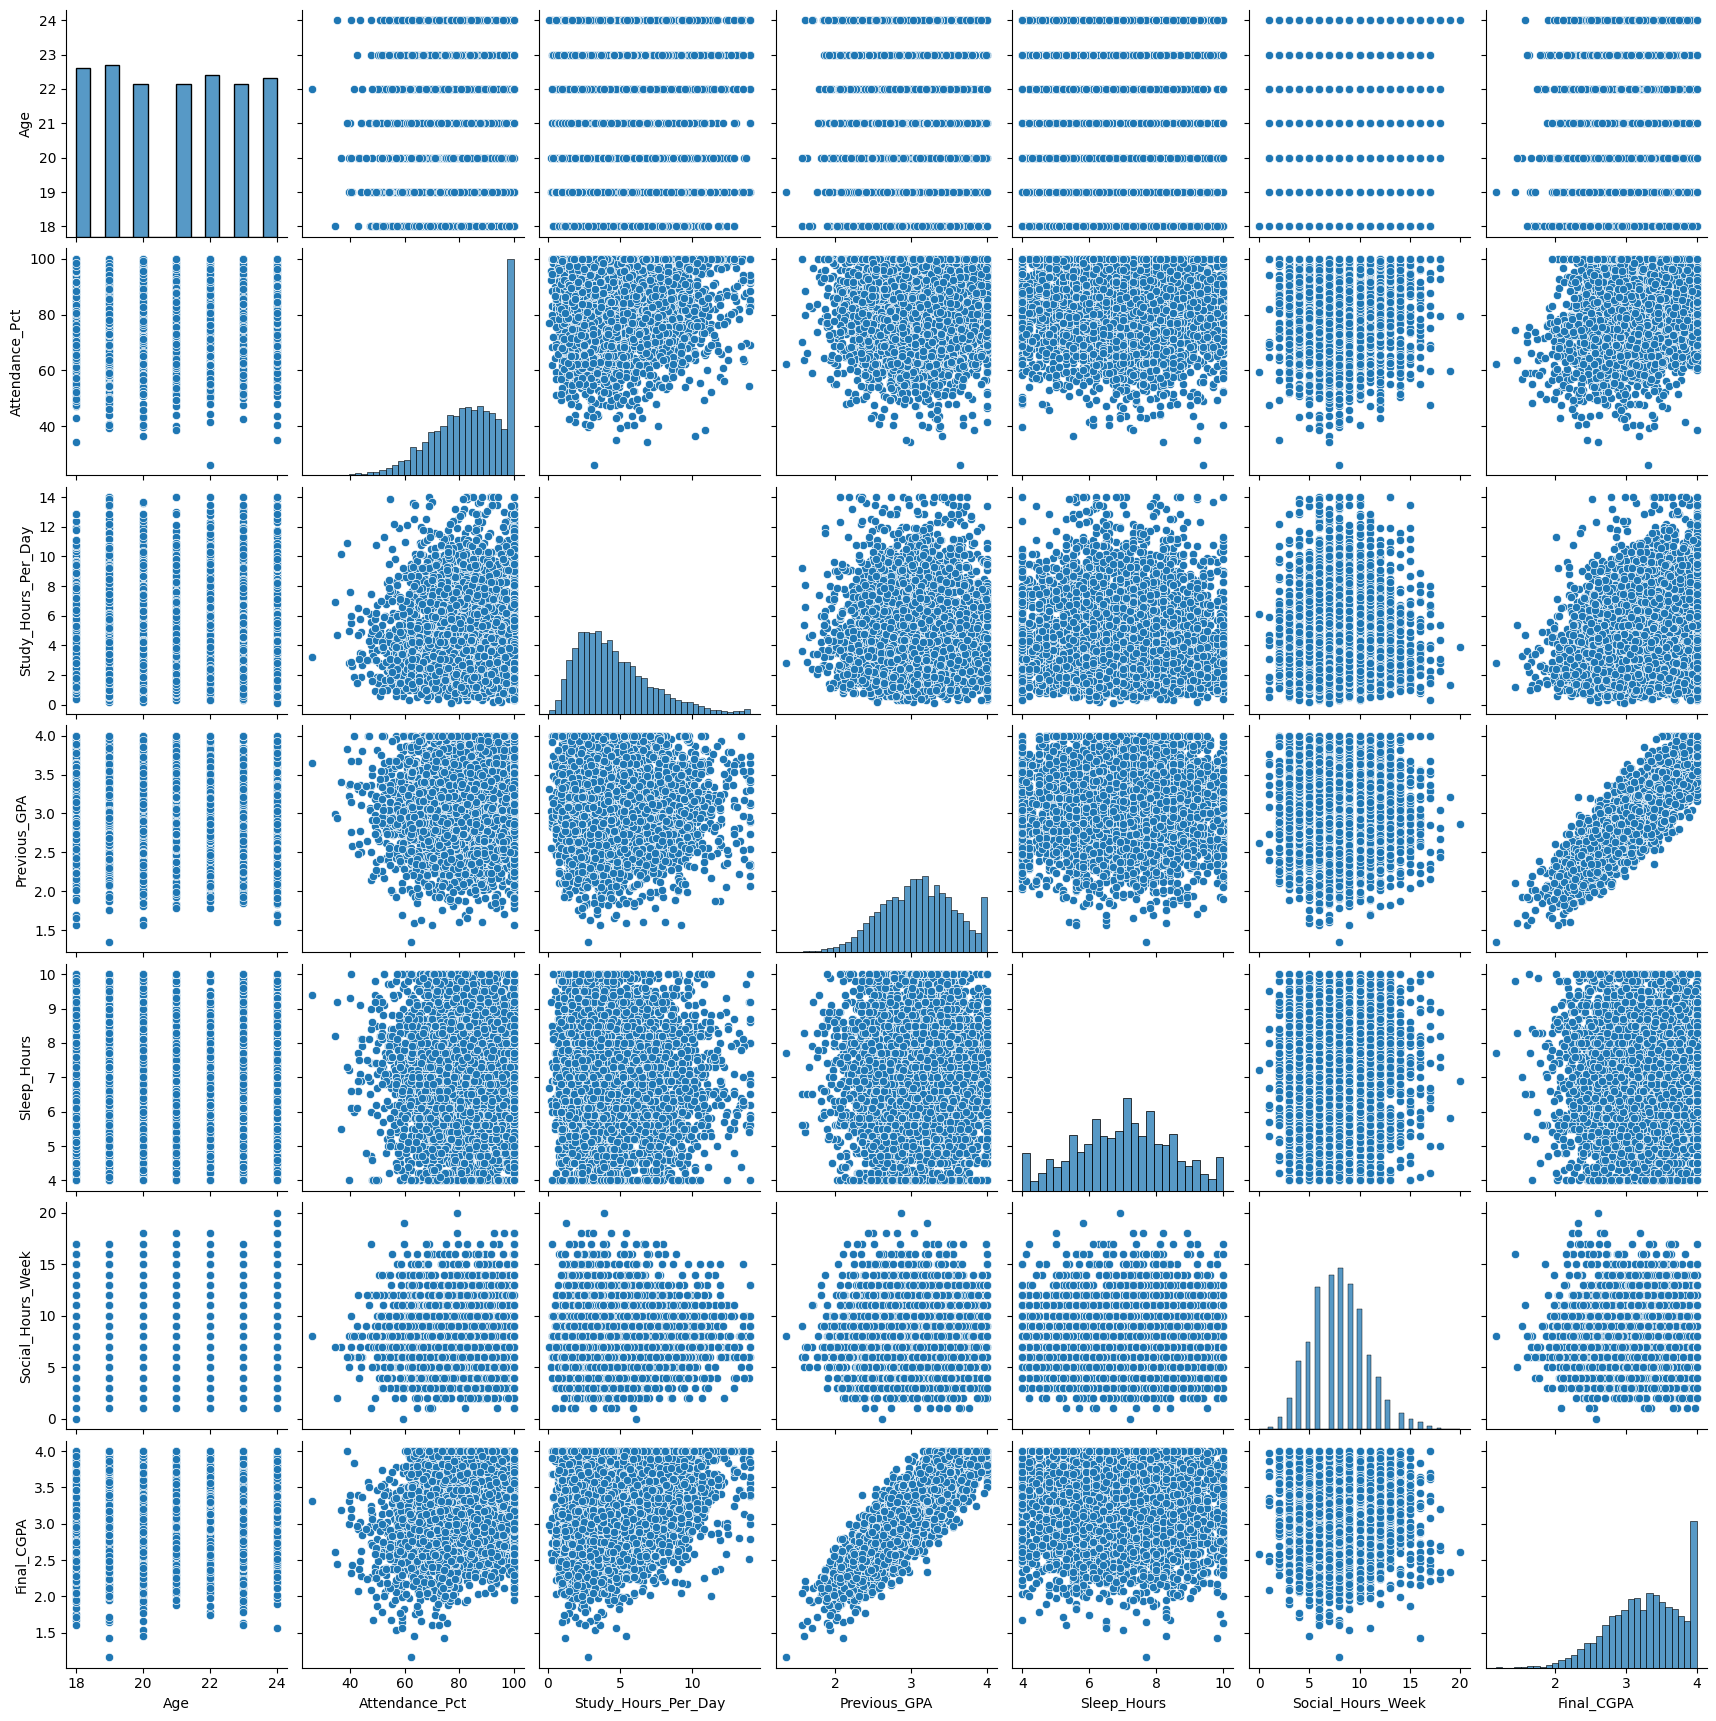

In [155]:
sns.pairplot(data_new)

По графикам видно, что особо никакие данные не связаны друг с другом, кроме финальной и прошлогодней оценки стедента. 
Ниже с помощью параметра "hue" была произведена группировка по значениям финальной оценки, но наглядности это не добавило 🙈

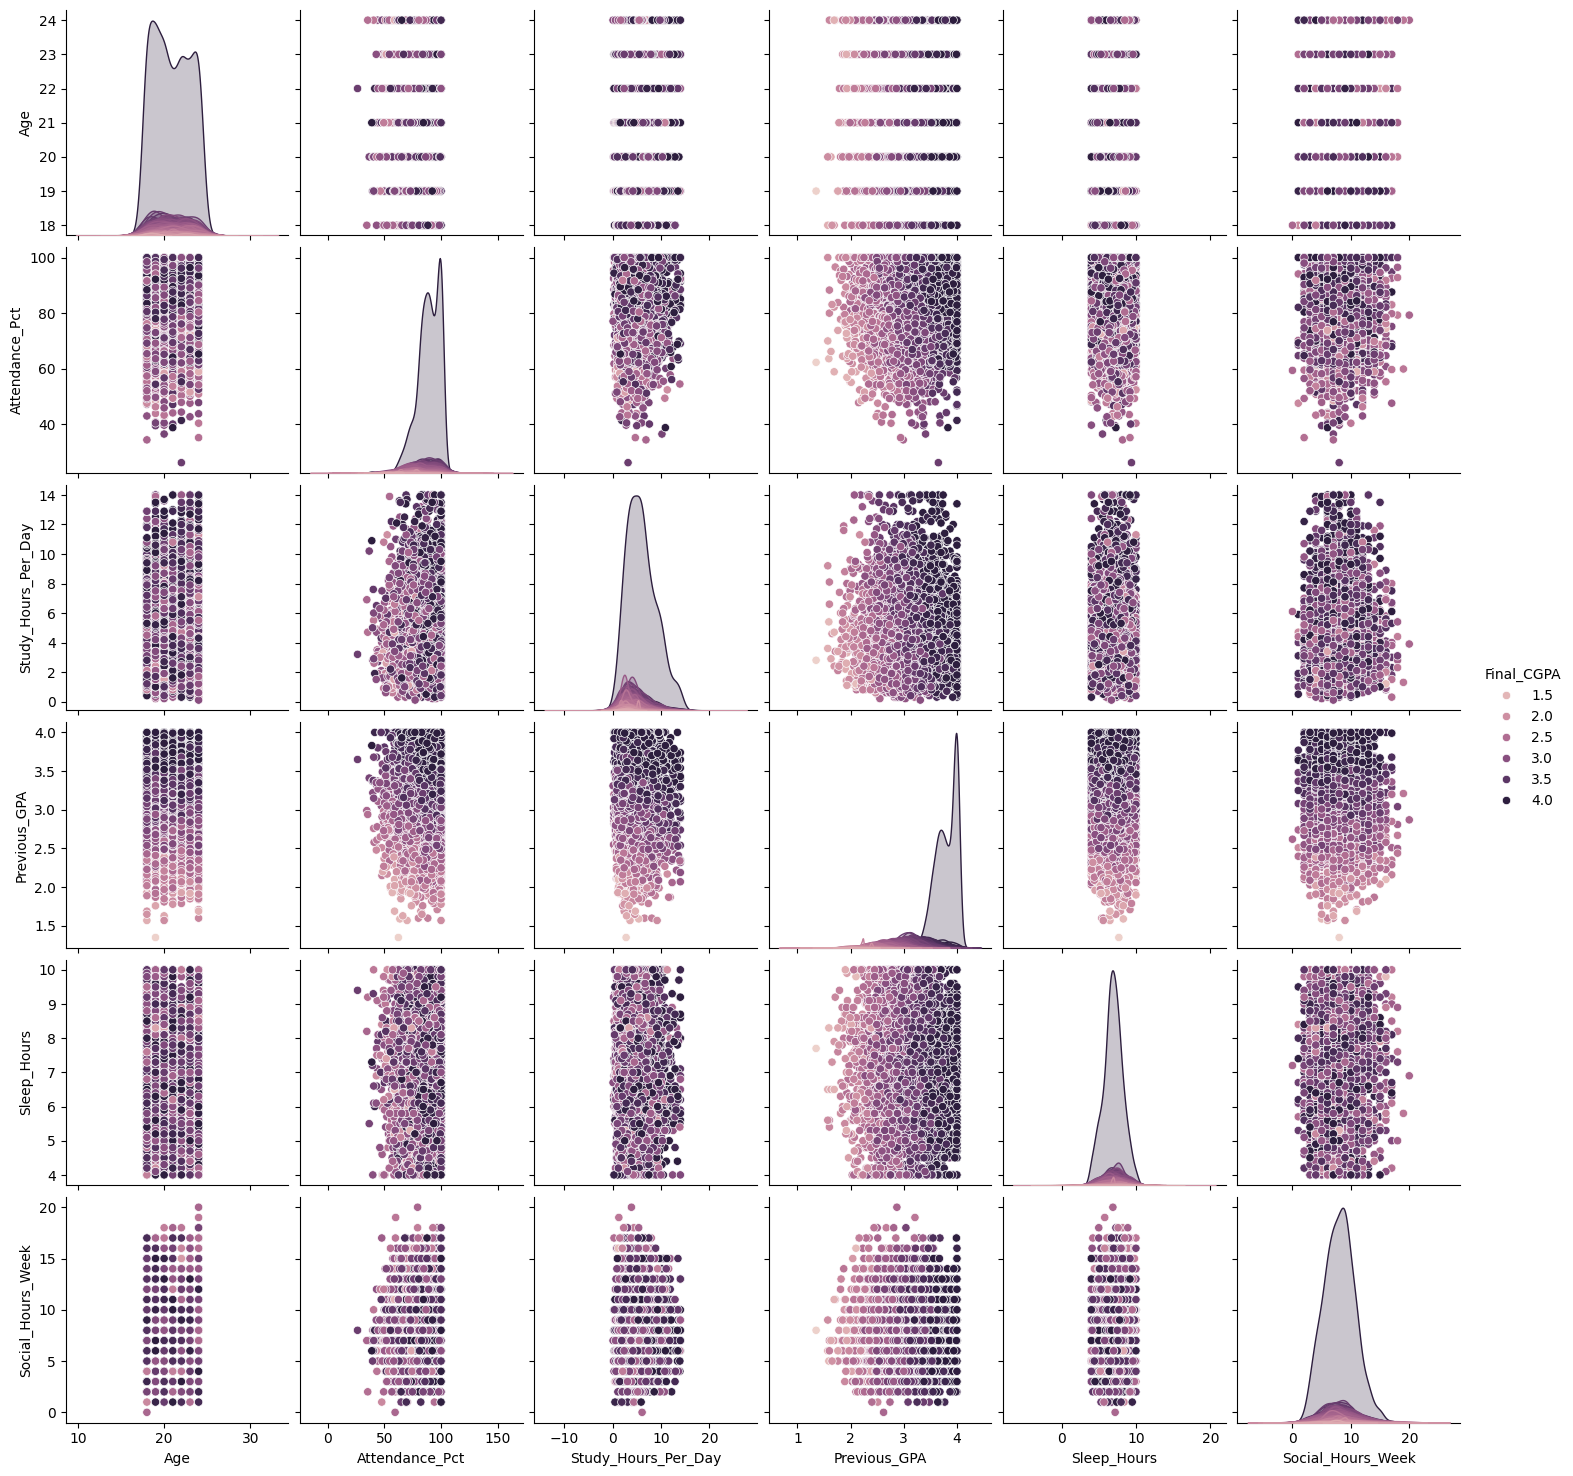

In [157]:
sns.pairplot(data, hue="Final_CGPA")

Ящик с усами

Отображает одномерное распределение вероятности.

<Axes: xlabel='Final_CGPA'>

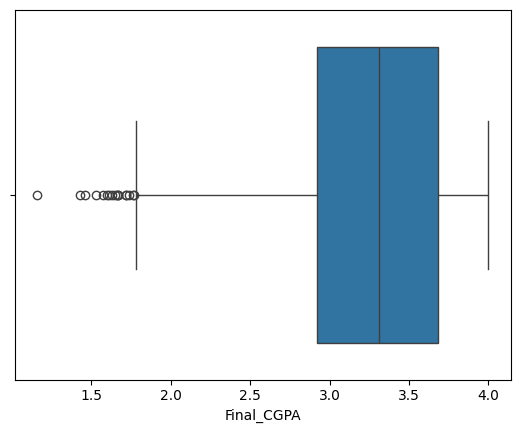

In [158]:
sns.boxplot(x=data['Final_CGPA']) #по горизонтали, по вертикали y = ...

<Axes: xlabel='Gender', ylabel='Final_CGPA'>

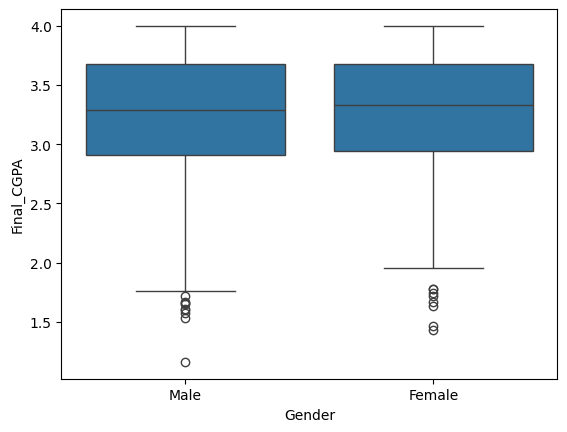

In [159]:
#Распределение по полу
sns.boxplot(x='Gender', y='Final_CGPA', data=data)

Violin plot

Как ящик с усами, но вместо ящика - график плотности распределения.

<Axes: xlabel='Final_CGPA'>

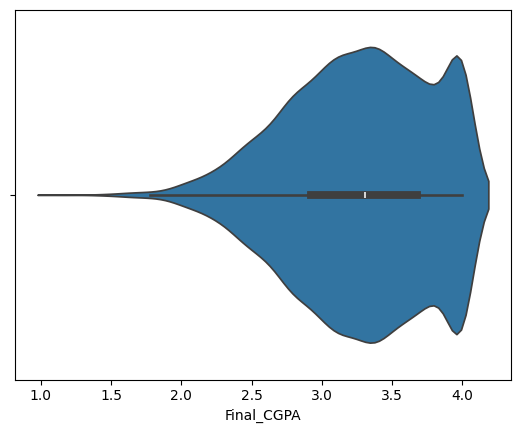

In [160]:
sns.violinplot(x=data['Final_CGPA'])

## Информация о корреляции признаков

In [161]:
data_new.corr()

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
Age,1.000000,0.023755,0.010266,-0.024369,0.003738,0.003921,-0.012245
Attendance_Pct,0.023755,1.000000,0.022700,0.024346,-0.017246,0.011411,0.302840
Study_Hours_Per_Day,0.010266,0.022700,1.000000,-0.003302,-0.021983,0.002351,0.230898
Previous_GPA,-0.024369,0.024346,-0.003302,1.000000,0.012845,0.012686,0.878879
Sleep_Hours,0.003738,-0.017246,-0.021983,0.012845,1.000000,0.006848,0.002617
Social_Hours_Week,0.003921,0.011411,0.002351,0.012686,0.006848,1.000000,-0.004927
Final_CGPA,-0.012245,0.302840,0.230898,0.878879,0.002617,-0.004927,1.000000


Корреляционная матрица содержит коэффициенты корреляции между всеми парами признаков.

Корреляционная матрица симметрична относительно главной диагонали. На главной диагонали расположены единицы (корреляция признака самого с собой).

На основе корреляционной матрицы можно сделать следующие выводы: целевой признак (в моем случае это финальная оценка, Final_CGPA) больше всего коррелирует с прошлогодней оценкой (0.87), что было понятно и по графикам выше, а так же немного коррелирует с Attendance_Pct (0,3) и Study_Hours_Per_Day (0,23), остальные признаки не влияют на оценку, значит их можно не использовать для модели.

По умолчанию при построении матрицы используется коэффициент корреляции Пирсона. Возможно также построить корреляционную матрицу на основе коэффициентов корреляции Кендалла и Спирмена. На практике три метода редко дают значимые различия.


In [162]:
data_new.corr(method='pearson')

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
Age,1.000000,0.023755,0.010266,-0.024369,0.003738,0.003921,-0.012245
Attendance_Pct,0.023755,1.000000,0.022700,0.024346,-0.017246,0.011411,0.302840
Study_Hours_Per_Day,0.010266,0.022700,1.000000,-0.003302,-0.021983,0.002351,0.230898
Previous_GPA,-0.024369,0.024346,-0.003302,1.000000,0.012845,0.012686,0.878879
Sleep_Hours,0.003738,-0.017246,-0.021983,0.012845,1.000000,0.006848,0.002617
Social_Hours_Week,0.003921,0.011411,0.002351,0.012686,0.006848,1.000000,-0.004927
Final_CGPA,-0.012245,0.302840,0.230898,0.878879,0.002617,-0.004927,1.000000


In [163]:
data_new.corr(method='kendall')

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
Age,1.000000,0.015366,0.002420,-0.018534,0.002254,0.002856,-0.012254
Attendance_Pct,0.015366,1.000000,0.013737,0.017611,-0.011637,0.007972,0.188258
Study_Hours_Per_Day,0.002420,0.013737,1.000000,-0.001130,-0.014724,0.002736,0.151372
Previous_GPA,-0.018534,0.017611,-0.001130,1.000000,0.013544,0.011995,0.703249
Sleep_Hours,0.002254,-0.011637,-0.014724,0.013544,1.000000,-0.001285,0.002253
Social_Hours_Week,0.002856,0.007972,0.002736,0.011995,-0.001285,1.000000,0.007523
Final_CGPA,-0.012254,0.188258,0.151372,0.703249,0.002253,0.007523,1.000000


In [164]:
data_new.corr(method='spearman')

,Age,Attendance_Pct,Study_Hours_Per_Day,Previous_GPA,Sleep_Hours,Social_Hours_Week,Final_CGPA
Age,1.000000,0.021688,0.003439,-0.025808,0.003302,0.003696,-0.017010
Attendance_Pct,0.021688,1.000000,0.020287,0.026095,-0.016874,0.011304,0.275376
Study_Hours_Per_Day,0.003439,0.020287,1.000000,-0.001730,-0.021666,0.004081,0.222618
Previous_GPA,-0.025808,0.026095,-0.001730,1.000000,0.020077,0.016969,0.880651
Sleep_Hours,0.003302,-0.016874,-0.021666,0.020077,1.000000,-0.002038,0.003552
Social_Hours_Week,0.003696,0.011304,0.004081,0.016969,-0.002038,1.000000,0.010762
Final_CGPA,-0.017010,0.275376,0.222618,0.880651,0.003552,0.010762,1.000000


Построим тепловую карту корреляций

<Axes: >

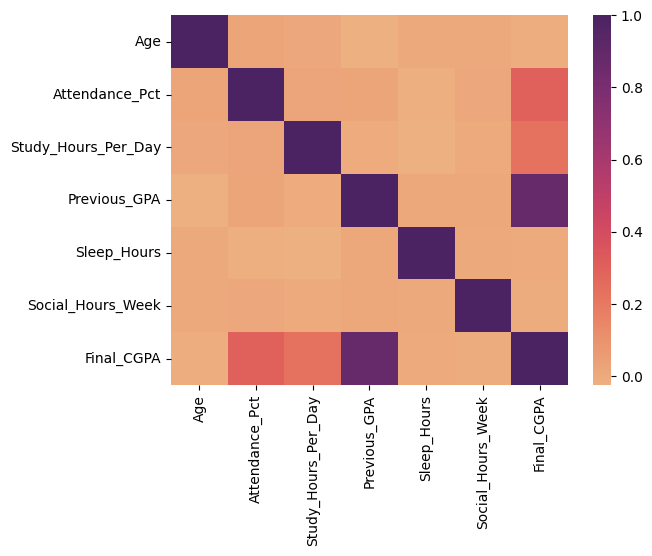

In [170]:
sns.heatmap(data_new.corr(),cmap='flare') #оранжево-фиолетовая

<Axes: >

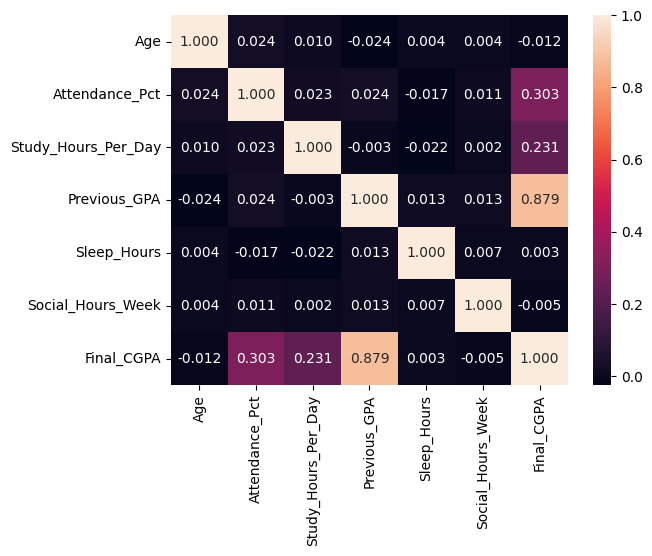

In [ ]:
sns.heatmap(data_new.corr(),annot=True, fmt='.3f') #со значениями

<Axes: >

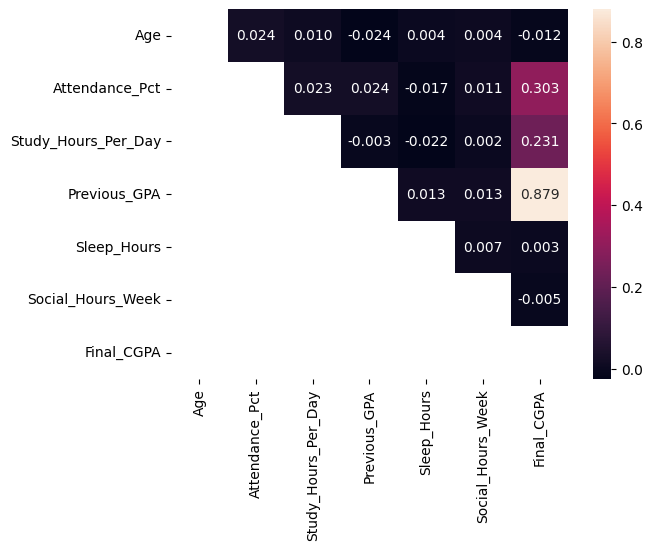

In [173]:
# Треугольный вариант матрицы
mask = np.zeros_like(data_new.corr(), dtype=np.bool)
# чтобы оставить нижнюю часть матрицы
# mask[np.triu_indices_from(mask)] = True
# чтобы оставить верхнюю часть матрицы
mask[np.tril_indices_from(mask)] = True
sns.heatmap(data_new.corr(), mask=mask, annot=True, fmt='.3f')

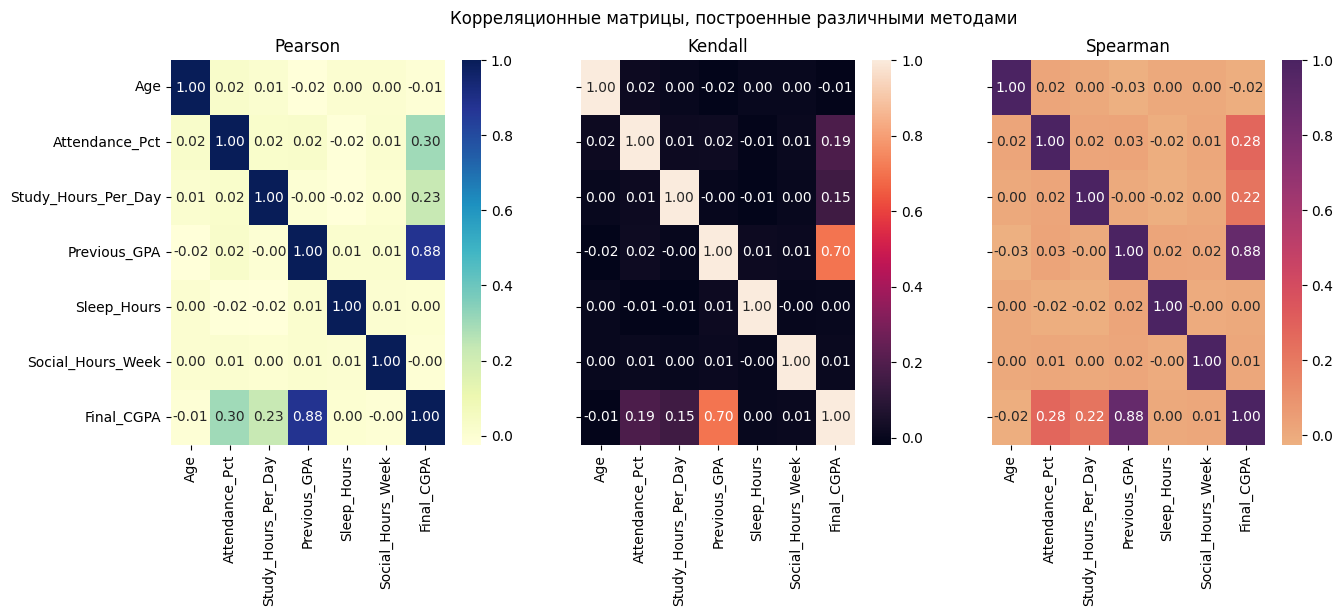

In [172]:
#Разноцветные со значениями разных способов подсчета корреляций
fig, ax = plt.subplots(1, 3, sharex='col', sharey='row', figsize=(15,5))
sns.heatmap(data_new.corr(method='pearson'),cmap='YlGnBu', ax=ax[0], annot=True, fmt='.2f')
sns.heatmap(data_new.corr(method='kendall'), ax=ax[1], annot=True, fmt='.2f')
sns.heatmap(data_new.corr(method='spearman'),cmap='flare', ax=ax[2], annot=True, fmt='.2f')
fig.suptitle('Корреляционные матрицы, построенные различными методами')
ax[0].title.set_text('Pearson')
ax[1].title.set_text('Kendall')
ax[2].title.set_text('Spearman')